<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%202/Week_2_Lecture_3_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=f4mL4Thr9hc) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%202/DL4CV_Week02_Part03.pdf)

In [ ]:
# Week 2, Lecture 3: Scale Space etc
from IPython.display import HTML, display

VIDEO_ID = "f4mL4Thr9hc"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

Watch on YouTube

# Week 2, Lecture 3: Scale Space, Image Pyramids and Filter Banks

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§2.3 Scale Space, Image Pyramids and Filter Banks**.

**What you will learn**

- Select a **characteristic scale** automatically from the scale signature.
- Build **Gaussian and Laplacian pyramids**, and use them for coarse-to-fine registration.
- See why a histogram alone cannot describe **texture**.
- Build **Gabor filters** and **filter banks**, and understand what makes a filter **steerable**.

**Contents**
1. Automatic scale selection: the scale signature
2. The Gaussian pyramid
3. The Laplacian pyramid
4. Coarse-to-fine registration
5. Texture: why a histogram is not enough
6. Gabor filters
7. Filter banks
8. Steerable filters

**How to run**  Runs on Colab or a local Jupyter, CPU only. Every image is bundled with `scikit-image`, so nothing is downloaded. Run the setup cell first, then go top to bottom.

## Review

The previous lecture detected corners with the Harris operator over a fixed window. A corner seen through a small window can look like an edge through a large one, so the Harris response is not scale invariant.

This lecture builds the machinery for handling scale directly:
- choosing a characteristic scale for a structure (automatic scale selection),
- the Gaussian and Laplacian pyramids that make multi-scale processing cheap,
- texture description with filter banks, including Gabor and steerable filters.

## Setup

Everything uses images bundled with `scikit-image` or generated synthetically, so the notebook runs offline. Two helpers are shared across sections.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import data, util, color

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap']     = 'gray'
plt.rcParams['figure.dpi']     = 85

def load_gray(image):
    return color.rgb2gray(image) if image.ndim == 3 else util.img_as_float(image)

def show(ax, im, title='', cmap='gray'):
    ax.imshow(im, cmap=cmap); ax.set_title(title); ax.axis("off")

## 1. Automatic scale selection: the scale signature

To match interest points across images taken at different zoom, each point needs a *characteristic scale* that the detector picks the same way in every image.

The recipe is to evaluate a scale-dependent function at a point over a range of scales and read off the scale where it peaks. A good choice is the **scale-normalized Laplacian of Gaussian**

$$
\mathrm{LoG}_{\text{norm}}(x, y; \sigma) = \sigma^2 \, \nabla^2 \big( g_\sigma * I \big)(x, y).
$$

The $\sigma^2$ factor cancels the natural decay of derivative amplitude with scale, so responses are comparable across scales. For a bright disk of radius $r$ the response magnitude peaks at

$$
\sigma^\star = \frac{r}{\sqrt 2},
\qquad
\text{recovered radius} = \sigma^\star \sqrt 2 .
$$

Plotting the response against $\sigma$ at a fixed point gives a **scale signature**, and its peak is the characteristic scale. Doubling the structure size doubles $\sigma^\star$, which is what makes the scale comparable across images.

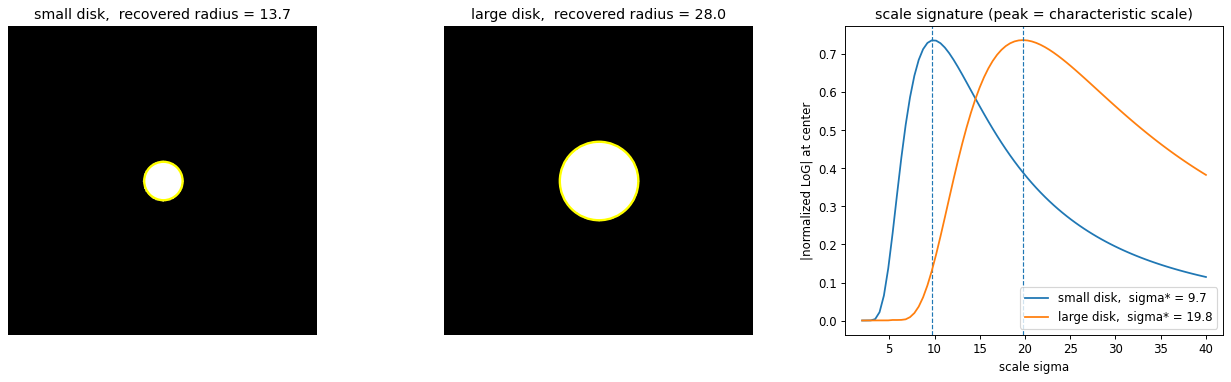

In [2]:
def disk(n, cx, cy, r):
    yy, xx = np.mgrid[0:n, 0:n]
    return ((xx - cx)**2 + (yy - cy)**2 <= r**2).astype(float)

def norm_log(im, sigma):                       # scale-normalized LoG
    return sigma**2 * ndi.gaussian_laplace(im, sigma)

def signature(im, sigmas, p):                  # |normalized LoG| at point p over scales
    return np.array([abs(norm_log(im, s)[p]) for s in sigmas])

n = 220
small, big = disk(n, n//2, n//2, 14), disk(n, n//2, n//2, 28)
sigmas = np.linspace(2, 40, 80)
p = (n//2, n//2)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
for a, im, name in [(ax[0], small, 'small disk'), (ax[1], big, 'large disk')]:
    sg = signature(im, sigmas, p)
    s_star = sigmas[sg.argmax()]
    show(a, im, f'{name},  recovered radius = {s_star * np.sqrt(2):.1f}')
    a.add_patch(plt.Circle(p[::-1], s_star * np.sqrt(2), color='yellow', fill=False, lw=2))
    ax[2].plot(sigmas, sg, label=f'{name},  sigma* = {s_star:.1f}')
    ax[2].axvline(s_star, ls='--', lw=1)
ax[2].set_xlabel('scale sigma'); ax[2].set_ylabel('|normalized LoG| at center')
ax[2].set_title('scale signature (peak = characteristic scale)'); ax[2].legend()
plt.tight_layout(); plt.show()

## 2. The Gaussian pyramid

Evaluating a function at many scales by enlarging the window is wasteful. The equivalent and cheaper route fixes the window and shrinks the image. Repeatedly smoothing and downsampling by two builds a **Gaussian pyramid**

$$
G_0 = I,
\qquad
G_{k+1} = \big( g_\sigma * G_k \big) \downarrow_2 ,
$$

where $\downarrow_2$ keeps every second pixel. Smoothing before subsampling is essential: it removes frequencies above the new Nyquist limit and prevents aliasing. Each level has half the resolution of the one below, so the whole pyramid costs only about $\tfrac{4}{3}$ the pixels of the original.

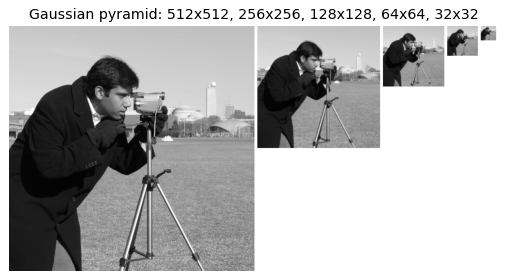

In [3]:
def gaussian_pyramid(im, levels, sigma=1.0):
    pyr = [im]
    for _ in range(levels - 1):
        pyr.append(ndi.gaussian_filter(pyr[-1], sigma)[::2, ::2])
    return pyr

def montage(levels, pad=6):                    # place levels side by side at true size
    H = levels[0].shape[0]
    W = sum(p.shape[1] for p in levels) + pad * len(levels)
    canvas = np.ones((H, W))
    x = 0
    for p in levels:
        h, w = p.shape
        canvas[:h, x:x + w] = p
        x += w + pad
    return canvas

img = load_gray(data.camera())[:512, :512]
gp = gaussian_pyramid(img, 5)

fig, ax = plt.subplots(figsize=(13, 3.4))
show(ax, montage(gp), 'Gaussian pyramid: ' + ', '.join(f'{p.shape[0]}x{p.shape[1]}' for p in gp))
plt.tight_layout(); plt.show()

## 3. The Laplacian pyramid

Each Gaussian level discards the detail removed by smoothing. The **Laplacian pyramid** stores that lost detail as the difference between a level and a blurred, upsampled copy of the next coarser level

$$
L_k = G_k - \mathrm{expand}(G_{k+1}),
\qquad
L_{N-1} = G_{N-1}.
$$

Here $\mathrm{expand}$ upsamples by inserting zeros and smoothing. Each $L_k$ is a band-pass image: it holds the frequencies present at level $k$ but absent at level $k+1$.

The representation is **invertible**. Using the same expand operator,

$$
G_k = L_k + \mathrm{expand}(G_{k+1}),
$$

telescopes back to the original image exactly, which is why Laplacian pyramids are used for blending and compression.

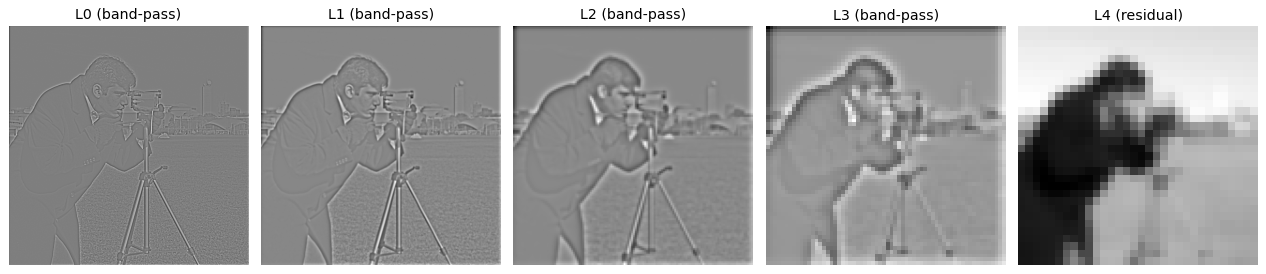

reconstruction max abs error: 1.1102230246251565e-16


In [4]:
def expand(small, out_shape, sigma=1.4):       # zero-insert upsample then smooth
    up = np.zeros(out_shape)
    up[::2, ::2] = small[:(out_shape[0] + 1)//2, :(out_shape[1] + 1)//2]
    return ndi.gaussian_filter(up, sigma) * 4.0

def laplacian_pyramid(im, levels, sigma=1.0):
    g = gaussian_pyramid(im, levels, sigma)
    lap = [g[k] - expand(g[k + 1], g[k].shape) for k in range(levels - 1)]
    lap.append(g[-1])                          # coarsest level kept as the residual
    return lap

def reconstruct(lap):
    img = lap[-1]
    for k in range(len(lap) - 2, -1, -1):
        img = lap[k] + expand(img, lap[k].shape)
    return img

lp  = laplacian_pyramid(img, 5)
rec = reconstruct(lp)

fig, ax = plt.subplots(1, 5, figsize=(15, 3.4))
for k in range(4):
    show(ax[k], lp[k], f'L{k} (band-pass)')
show(ax[4], lp[4], 'L4 (residual)')
plt.tight_layout(); plt.show()

print('reconstruction max abs error:', np.abs(rec - img).max())

## 4. Coarse-to-fine registration

Aligning two images by searching all displacements at full resolution is expensive. The pyramid turns it into a small search at each scale.

Algorithm:
1. Build a Gaussian pyramid of both images.
2. Estimate the displacement at the coarsest level with a small search.
3. Double the estimate and pass it to the next finer level.
4. Refine there with a tiny search of a pixel or two.
5. Repeat down to full resolution.

A displacement of $d$ pixels at full resolution is only $d / 2^{N-1}$ at the coarsest level, so a small window there already covers it. Each finer level corrects the estimate locally, so the search range stays tiny throughout.

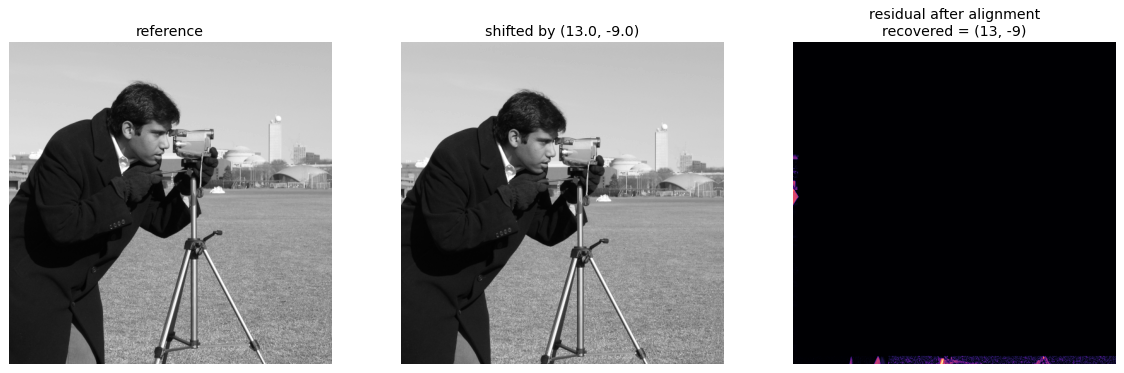

true shift (13.0, -9.0), recovered (13, -9)
candidates evaluated coarse-to-fine: 148   vs single-level brute force +-16: 1089


In [5]:
def ssd(a, b):
    return np.mean((a - b)**2)

def search_shift(ref, mov, center, radius, margin=6):
    H, W = ref.shape; cy, cx = center
    best, best_s = np.inf, center
    for dy in range(cy - radius, cy + radius + 1):
        for dx in range(cx - radius, cx + radius + 1):
            s = ndi.shift(mov, (-dy, -dx), order=1, mode='reflect')
            e = ssd(ref[margin:H - margin, margin:W - margin],
                    s[margin:H - margin, margin:W - margin])
            if e < best:
                best, best_s = e, (dy, dx)
    return best_s

ref = load_gray(data.camera())[:512, :512]
true_shift = (13.0, -9.0)
mov = ndi.shift(ref, true_shift, order=3, mode='reflect')

levels = 4
rp, mp = gaussian_pyramid(ref, levels), gaussian_pyramid(mov, levels)
est, evaluated = (0, 0), 0
for lvl in reversed(range(levels)):
    if lvl == levels - 1:
        radius, center = 5, (0, 0)            # wider search on the tiny coarse image
    else:
        est = (est[0] * 2, est[1] * 2)        # propagate estimate to the finer level
        radius, center = 1, est
    est = search_shift(rp[lvl], mp[lvl], center, radius)
    evaluated += (2 * radius + 1)**2

aligned = ndi.shift(mov, (-est[0], -est[1]), order=1, mode='reflect')
fig, ax = plt.subplots(1, 3, figsize=(14, 4.4))
show(ax[0], ref, 'reference')
show(ax[1], mov, f'shifted by {true_shift}')
show(ax[2], np.abs(ref - aligned), f'residual after alignment\nrecovered = {est}', cmap='magma')
plt.tight_layout(); plt.show()

max_disp = 16
print(f'true shift {true_shift}, recovered {est}')
print(f'candidates evaluated coarse-to-fine: {evaluated}   '
      f'vs single-level brute force +-{max_disp}: {(2 * max_disp + 1)**2}')

## 5. Texture: why a histogram is not enough

Texture is the spatial arrangement of intensities, not just their distribution. Three patterns can share an identical intensity histogram yet look completely different: a block, a checkerboard, and stripes are each half black and half white.

A histogram ignores spatial layout, so it cannot tell them apart. What separates them is how they respond to **oriented filters**. The derivative-of-Gaussian filters $\partial_x g$ and $\partial_y g$ respond to vertical and horizontal edges respectively, and the mean absolute response already forms a small feature that pulls the three patterns apart. Richer texture descriptors extend this to many orientations and scales.

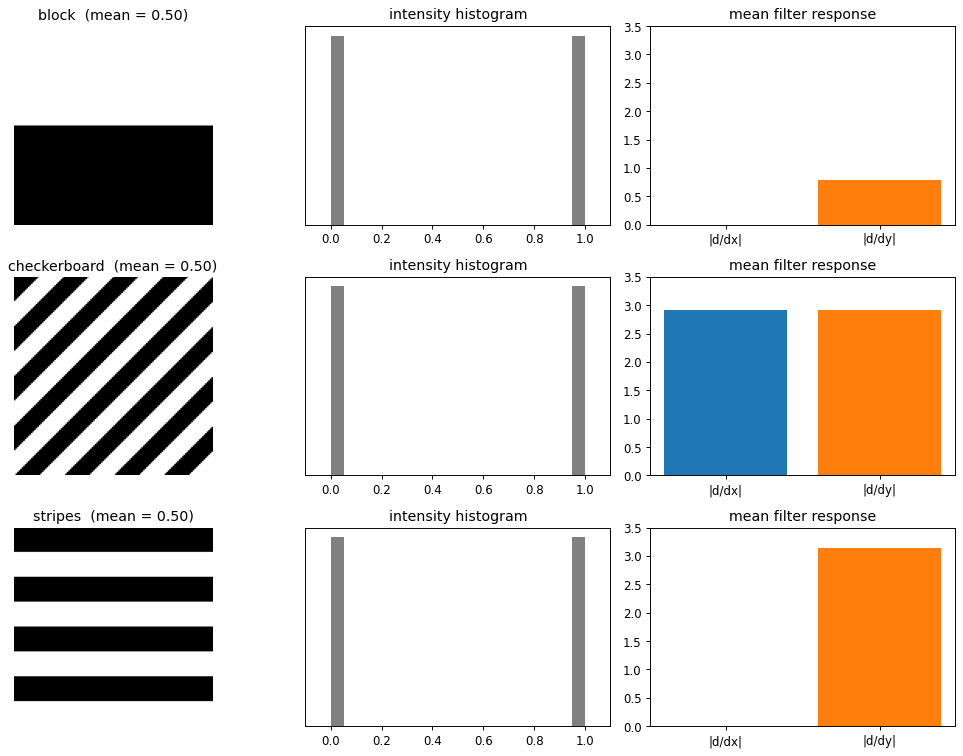

In [6]:
def block(n):      im = np.zeros((n, n)); im[:n//2] = 1; return im
def checker(n, k): return ((np.indices((n, n)).sum(0)//k) % 2).astype(float)
def stripes(n, k): col = (np.arange(n)//k) % 2; return np.repeat(col[:, None], n, 1).astype(float)

def dog(size, sigma, axis):                    # derivative of Gaussian
    r = size//2; y, x = np.mgrid[-r:r + 1, -r:r + 1]
    g = np.exp(-(x**2 + y**2)/(2*sigma**2))
    return (-x/sigma**2*g) if axis == 'x' else (-y/sigma**2*g)

n = 128
patterns = {'block': block(n), 'checkerboard': checker(n, 16), 'stripes': stripes(n, 16)}
fx, fy = dog(15, 3, 'x'), dog(15, 3, 'y')

fig, ax = plt.subplots(3, 3, figsize=(12, 9))
for i, (name, im) in enumerate(patterns.items()):
    rx = np.abs(ndi.convolve(im, fx, mode='wrap')).mean()
    ry = np.abs(ndi.convolve(im, fy, mode='wrap')).mean()
    show(ax[i, 0], im, f'{name}  (mean = {im.mean():.2f})')
    ax[i, 1].hist(im.ravel(), bins=20, color='gray')
    ax[i, 1].set_title('intensity histogram'); ax[i, 1].set_xlim(-0.1, 1.1); ax[i, 1].set_yticks([])
    ax[i, 2].bar(['|d/dx|', '|d/dy|'], [rx, ry], color=['tab:blue', 'tab:orange'])
    ax[i, 2].set_ylim(0, 3.5); ax[i, 2].set_title('mean filter response')
plt.tight_layout(); plt.show()

## 6. Gabor filters

A Gabor filter is a sinusoid of a chosen frequency and orientation multiplied by a Gaussian envelope. It responds to a narrow band of frequencies at a particular orientation, which makes it a natural texture and edge detector. The complex form is

$$
g(x, y) = \exp\!\left( -\frac{x'^2 + \gamma^2 y'^2}{2\sigma^2} \right)
          \exp\!\left( i \left( \frac{2\pi x'}{\lambda} + \psi \right) \right),
$$

with the coordinates rotated by the orientation $\theta$:

$$
x' = x\cos\theta + y\sin\theta,
\qquad
y' = -x\sin\theta + y\cos\theta .
$$

The parameters are
- $\theta$: orientation of the stripes,
- $\lambda$: wavelength of the sinusoid,
- $\psi$: phase offset,
- $\sigma$: width of the Gaussian envelope,
- $\gamma$: aspect ratio of the envelope.

The real part is an even (cosine) filter and the imaginary part is an odd (sine) filter.

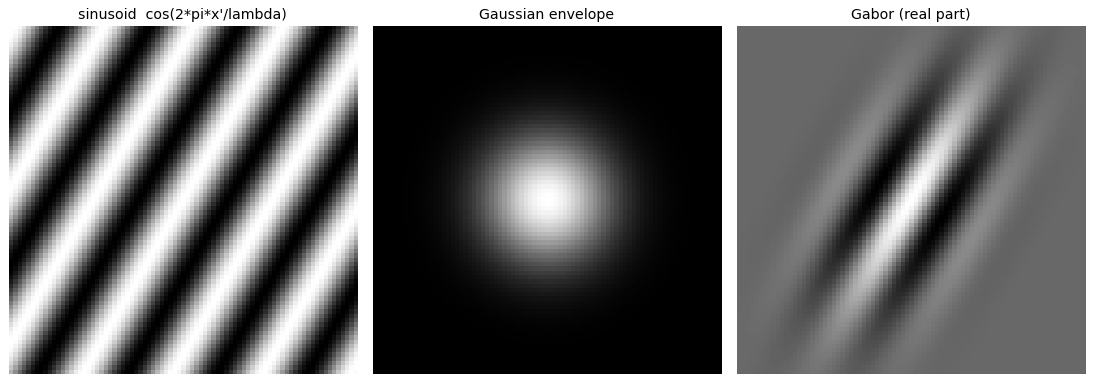

In [7]:
def gabor(size, lam, theta, psi=0.0, sigma=None, gamma=0.5):
    if sigma is None: sigma = 0.56 * lam       # envelope width for ~1 octave bandwidth
    r = size//2; y, x = np.mgrid[-r:r + 1, -r:r + 1]
    xr =  x*np.cos(theta) + y*np.sin(theta)
    yr = -x*np.sin(theta) + y*np.cos(theta)
    envelope = np.exp(-(xr**2 + gamma**2 * yr**2)/(2*sigma**2))
    carrier  = np.exp(1j*(2*np.pi*xr/lam + psi))
    return envelope * carrier

# sinusoid x Gaussian = Gabor
size, lam, theta = 81, 18, np.deg2rad(30)
r = size//2; y, x = np.mgrid[-r:r + 1, -r:r + 1]
xr = x*np.cos(theta) + y*np.sin(theta)
sinusoid = np.cos(2*np.pi*xr/lam)
envelope = np.exp(-(x**2 + y**2)/(2*(0.56*lam)**2))

fig, ax = plt.subplots(1, 3, figsize=(13, 4.4))
show(ax[0], sinusoid, "sinusoid  cos(2*pi*x'/lambda)")
show(ax[1], envelope, 'Gaussian envelope')
show(ax[2], gabor(size, lam, theta).real, 'Gabor (real part)')
plt.tight_layout(); plt.show()

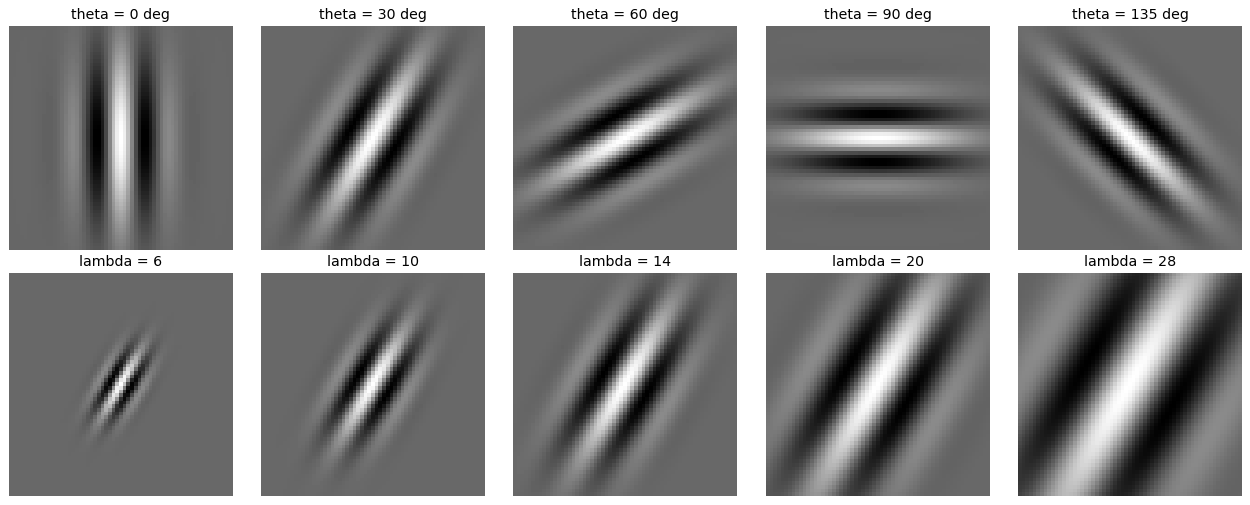

In [8]:
# effect of orientation (top) and wavelength (bottom)
fig, ax = plt.subplots(2, 5, figsize=(15, 6))
for j, deg in enumerate([0, 30, 60, 90, 135]):
    show(ax[0, j], gabor(61, 14, np.deg2rad(deg)).real, f'theta = {deg} deg')
for j, lam in enumerate([6, 10, 14, 20, 28]):
    show(ax[1, j], gabor(61, lam, np.deg2rad(30)).real, f'lambda = {lam}')
plt.tight_layout(); plt.show()

## 7. Filter banks

A **filter bank** is a collection of band-pass filters tuned to different orientations and scales. Running an image through the bank and keeping the responses (or their magnitudes) describes the local structure: which orientations and frequencies are present at each location.

A bank of Gabor filters at evenly spaced orientations is a common choice. Below, sixteen filters spaced $11.25^\circ$ apart are applied to a circle. Each filter responds most where the contour is tangent to its orientation, so the bright arc rotates around the circle as the orientation advances. The same bank applied to a natural texture gives a stack of orientation and scale specific responses.

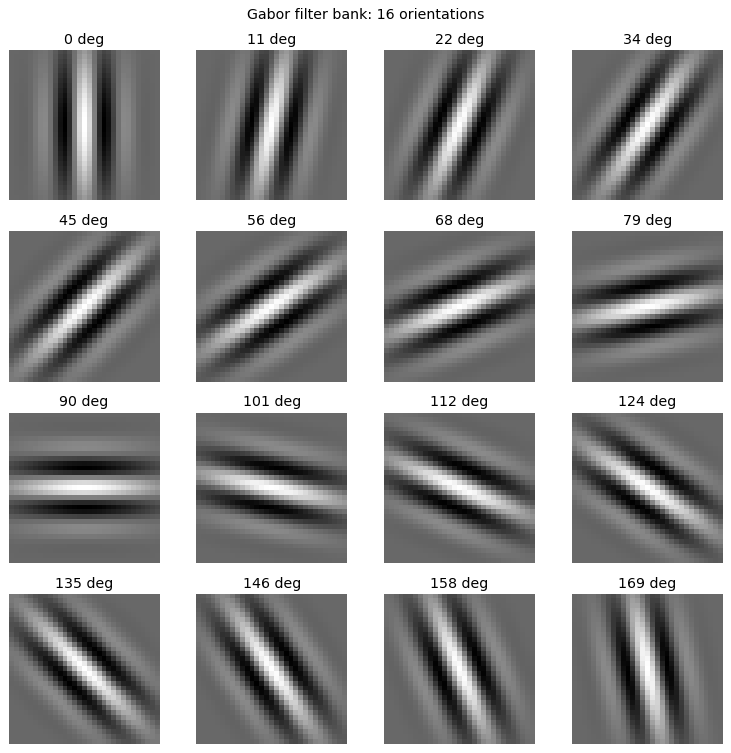

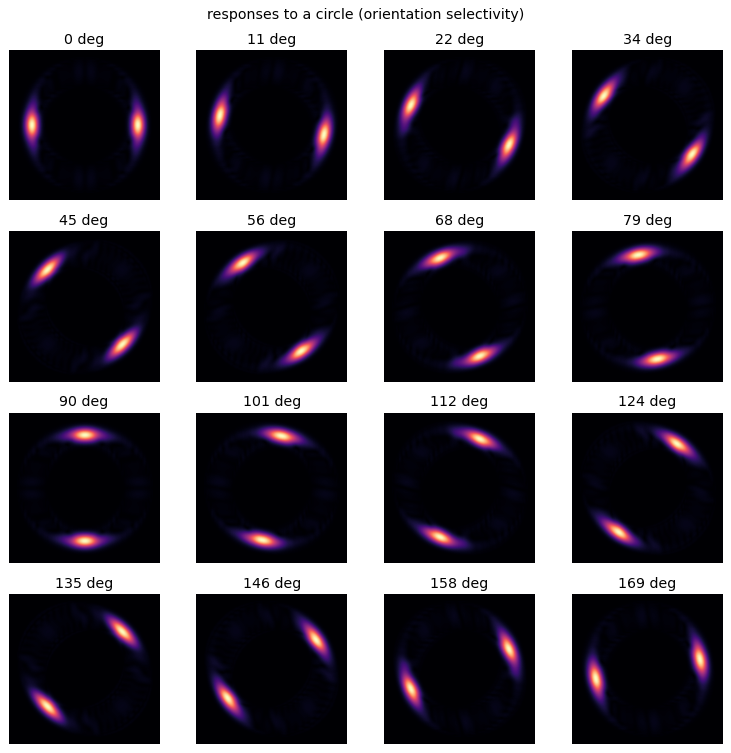

In [9]:
def circle_img(n, r, w=1.3):
    yy, xx = np.mgrid[0:n, 0:n]
    d = np.sqrt((xx - n/2)**2 + (yy - n/2)**2)
    return (np.abs(d - r) < w).astype(float)

def gabor_magnitude(im, k):                    # magnitude of the complex Gabor response
    re = ndi.convolve(im, k.real, mode='reflect')
    od = ndi.convolve(im, k.imag, mode='reflect')
    return np.hypot(re, od)

thetas = np.linspace(0, np.pi, 16, endpoint=False)
bank = [gabor(31, 9, t) for t in thetas]
circ = circle_img(170, 60)

fig, ax = plt.subplots(4, 4, figsize=(9, 9))
for j, k in enumerate(bank):
    show(ax.flat[j], k.real, f'{np.rad2deg(thetas[j]):.0f} deg')
fig.suptitle('Gabor filter bank: 16 orientations'); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(4, 4, figsize=(9, 9))
for j, k in enumerate(bank):
    show(ax.flat[j], gabor_magnitude(circ, k), f'{np.rad2deg(thetas[j]):.0f} deg', cmap='magma')
fig.suptitle('responses to a circle (orientation selectivity)'); plt.tight_layout(); plt.show()

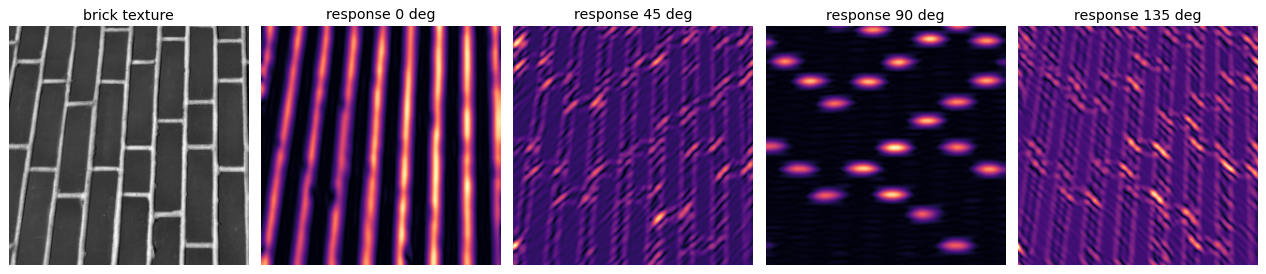

In [10]:
# the same bank on a natural texture, one scale, four orientations
brick = load_gray(data.brick())[:256, :256]
fig, ax = plt.subplots(1, 5, figsize=(15, 3.4))
show(ax[0], brick, 'brick texture')
for j, deg in enumerate([0, 45, 90, 135]):
    k = gabor(21, 7, np.deg2rad(deg))
    show(ax[j + 1], gabor_magnitude(brick, k), f'response {deg} deg', cmap='magma')
plt.tight_layout(); plt.show()

## 8. Steerable filters

Applying a whole bank to recover every orientation is wasteful when the filters are related. A filter is **steerable** if an oriented copy at any angle is an exact linear combination of a small fixed set of basis filters.

The first derivative of a Gaussian is the simplest example. With the two basis filters

$$
G^{0^\circ} = \partial_x g,
\qquad
G^{90^\circ} = \partial_y g,
$$

the derivative at any angle $\theta$ is

$$
G^{\theta} = \cos\theta \; G^{0^\circ} + \sin\theta \; G^{90^\circ}.
$$

Because convolution is linear, the same holds for the responses. Filter the image once with each basis filter to get $R_0$ and $R_{90}$, then the response of the $\theta$ oriented filter at every pixel is

$$
R_\theta = \cos\theta \; R_0 + \sin\theta \; R_{90},
$$

with no further filtering. Two convolutions give every orientation.

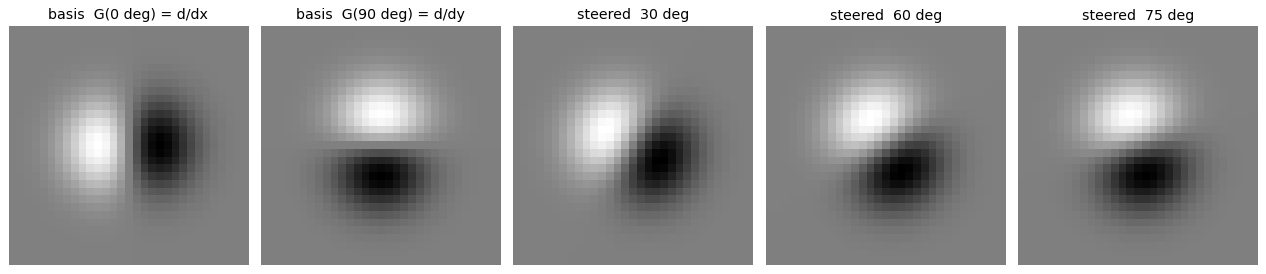

In [11]:
def gauss_xy(size, sigma):
    r = size//2; y, x = np.mgrid[-r:r + 1, -r:r + 1]
    return x, y, np.exp(-(x**2 + y**2)/(2*sigma**2))

def dgauss_dir(size, sigma, theta):            # 1st derivative of Gaussian along theta
    x, y, g = gauss_xy(size, sigma)
    return -(x*np.cos(theta) + y*np.sin(theta))/sigma**2 * g

size, sigma = 31, 4
x, y, g = gauss_xy(size, sigma)
G0, G90 = -x/sigma**2 * g, -y/sigma**2 * g     # the two basis filters

# basis filters and a few steered kernels
fig, ax = plt.subplots(1, 5, figsize=(15, 3.4))
show(ax[0], G0,  'basis  G(0 deg) = d/dx')
show(ax[1], G90, 'basis  G(90 deg) = d/dy')
for j, deg in enumerate([30, 60, 75]):
    t = np.deg2rad(deg)
    show(ax[j + 2], np.cos(t)*G0 + np.sin(t)*G90, f'steered  {deg} deg')
plt.tight_layout(); plt.show()

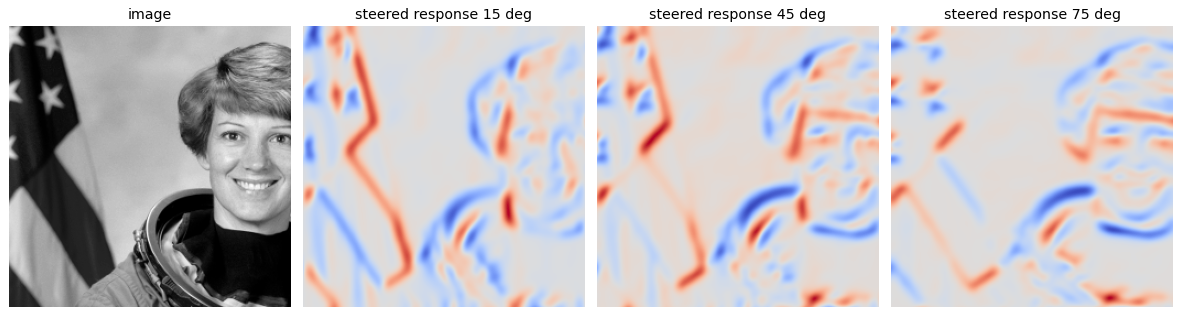

max |synthesized - directly filtered| over the three angles: 3.1530333899354446e-14


In [12]:
# response synthesis: filter twice, steer the response to any angle for free
pic = load_gray(data.astronaut())[:256, :256]
R0  = ndi.convolve(pic, G0,  mode='reflect')
R90 = ndi.convolve(pic, G90, mode='reflect')

fig, ax = plt.subplots(1, 4, figsize=(14, 3.8))
show(ax[0], pic, 'image')
for j, deg in enumerate([15, 45, 75]):
    t = np.deg2rad(deg)
    synth = np.cos(t)*R0 + np.sin(t)*R90
    show(ax[j + 1], synth, f'steered response {deg} deg', cmap='coolwarm')
plt.tight_layout(); plt.show()

# the synthesized response matches direct filtering with the oriented kernel
err = max(np.abs((np.cos(np.deg2rad(d))*R0 + np.sin(np.deg2rad(d))*R90)
                 - ndi.convolve(pic, dgauss_dir(size, sigma, np.deg2rad(d)), mode='reflect')).max()
          for d in [15, 45, 75])
print('max |synthesized - directly filtered| over the three angles:', err)

---

## Key takeaways

| Concept | Key takeaway |
|---|---|
| Characteristic scale | Peak of the scale-normalized LoG over $\sigma$; for a disk of radius $r$ it sits at $\sigma^\star = r/\sqrt 2$ |
| Scale signature | Response vs scale at a point; doubling the structure size doubles $\sigma^\star$ |
| Gaussian pyramid | Smooth then downsample by two; smoothing first prevents aliasing |
| Laplacian pyramid | $L_k = G_k - \mathrm{expand}(G_{k+1})$; band-pass and exactly invertible |
| Coarse-to-fine | Estimate displacement at the coarse scale, refine downward; a tiny search at every level |
| Texture | Spatial layout, not the histogram; oriented filter responses separate patterns with equal histograms |
| Filter bank | Band-pass filters over orientation and scale; keep the response magnitudes |
| Gabor filter | Sinusoid times a Gaussian; tuned to one frequency and orientation |
| Steerable filter | The oriented filter at any angle is a fixed linear combination of a few basis filters |

**Reading:** Szeliski, *Computer Vision: Algorithms and Applications*, Ch. 2.

**To think about:** Why is camouflage effective, and how? How is texture different from noise? Will scale-invariant filters help match pictures of nested Matryoshka dolls?

## Exercises

1. **The signature tracks size.** Compute the scale signature at a point, then double the size of the structure and confirm the peak $\sigma^\star$ doubles.

2. **Laplacian pyramid is invertible.** Build $L_k = G_k - \mathrm{expand}(G_{k+1})$, reconstruct the original, and confirm the error is at machine precision. What breaks if you skip the smoothing before downsampling?

3. **Coarse-to-fine registration.** Shift an image by a known offset, then recover it using a small search at each pyramid level. Compare the work done against a single full-resolution search.

4. **Texture needs layout.** Build two images with identical intensity histograms but different texture, and show a histogram cannot separate them while a Gabor filter bank can.